# Energie-Steckbriefe je Quartier

District "fact sheets" focused on **heat and electricity demand**, built on `buildings_unified.parquet`
(produced in `matching.ipynb` by geometry-overlap-matching ALKIS buildings against the solar,
electricity and heat datasets, with electricity/heat apportioned across shared zones so values are
additive and trustworthy for aggregation).

Two assumptions used throughout:

- **Specific (per-m²) demand** = building's apportioned demand ÷ estimated floor area
  (`grundflaeche × anzahlDerOberirdischenGeschosse`, the same proxy used for apportionment in
  `matching.ipynb`). Buildings that share an electricity/heat zone therefore show the *same*
  specific demand - that's the zone's average intensity, not fabricated per-building variation.
- **Solar annual yield** = `solar_power_value [kWp] × 950 kWh/kWp/year`, a rough flat-rate yield
  assumption for Hamburg-area rooftop PV, only used to compare solar *potential* against measured
  electricity demand - not a real generation forecast.

Reuses building-type classification (`classify_building_type`, `COLOR_MAP`) and the district
clipping helper (`limit_gdf`) from `quartier_analyse.py`, the module behind the original
Quartieranalyse reports (see `report.ipynb`).

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx
from shapely.geometry import Polygon
from matplotlib.gridspec import GridSpec

from quartier_analyse import classify_building_type, add_building_category, COLOR_MAP, limit_gdf, quelle

In [2]:
buildings_unified = gpd.read_parquet("buildings_unified.parquet")
print(buildings_unified.shape)
buildings_unified.head(2)

(381704, 35)


,identifier,beginnt,advStandardModell,gebaeudefunktion,anzahlDerOberirdischenGeschosse,dachform,grundflaeche,grundflaeche_uom,bauweise,baujahr,...,elec_zone_total,elec_n_buildings_in_zone,elec_match_score,heat_value,heat_zone_total,heat_n_buildings_in_zone,heat_match_score,solar_high_confidence,elec_high_confidence,heat_high_confidence
0,urn:adv:oid:DEHHALKAn0000WjZ,2012-03-28T08:54:41Z,DLKM,2463,1.0,3100.0,60.0,urn:adv:uom:m2,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False
1,urn:adv:oid:DEHHALKAn0000hoI,2022-05-17T12:06:44Z,DLKM,1010,2.0,3100.0,75.0,urn:adv:uom:m2,1100.0,1995.0,...,40.0,15.0,0.999997,19170.403587,114000.0,8.0,1.0,True,True,True


In [3]:
# Same four districts already analysed in report.ipynb / quartier_analyse.py.
districts = {
    "Wandsbek": [
        [10.071450882096563, 53.57343719771864],
        [10.078282200812708, 53.57582089436743],
        [10.086978353249249, 53.57780085497406],
        [10.088500780178016, 53.57786434031859],
        [10.08968943613927, 53.57528776626812],
        [10.090770539267197, 53.57544358156409],
        [10.09161951641922, 53.57351782519276],
        [10.081990170144394, 53.57132713390438],
        [10.07602700765947, 53.571645156140086],
        [10.07573490367003, 53.5721943741919],
        [10.072668065541466, 53.57226654319956],
    ],
    "Bergedorf": [
        [10.216092226707454, 53.48627516982354],
        [10.218062146262689, 53.48711948438419],
        [10.22129320145399, 53.48765909779577],
        [10.248617458364713, 53.48937887988561],
        [10.237444941913756, 53.48863637733065],
        [10.239514276676424, 53.482153550503696],
        [10.236664132702685, 53.478332344712726],
        [10.238828717395801, 53.47816374183119],
        [10.230081720930775, 53.47999190635718],
        [10.227874946078842, 53.48095295620313],
        [10.223303949312394, 53.482313709785295],
        [10.216013357040172, 53.48620500472692],
    ],
    "Harburger Hafen": [
        [9.997757570312924, 53.47174324776492],
        [9.99221253186944, 53.46069175850645],
        [9.984824272608028, 53.46272658242247],
        [9.963209190168682, 53.469433122908605],
        [9.952495521364472, 53.47064385798611],
        [9.96080638719249, 53.48301447925519],
        [9.976279977882369, 53.47688468924603],
    ],
    "City Nord": [
        [10.01806470193082, 53.61522442932927],
        [10.0097018715396, 53.61206474671362],
        [10.001020066635839, 53.6117167526437],
        [9.996227448288922, 53.60880920727803],
        [9.995003534011472, 53.60609159136859],
        [9.994365404346551, 53.60372162732476],
        [9.992821682024852, 53.60226787118915],
        [9.997348135579054, 53.60201570374794],
        [10.006507514863095, 53.59939376909675],
        [10.013536150748445, 53.599994211478105],
        [10.025250809714526, 53.60030937836359],
        [10.025199251765294, 53.60549151086822],
        [10.027169961889353, 53.60618642898026],
        [10.024135643962275, 53.610326172433325],
    ],
}

In [4]:
SPECIFIC_YIELD_KWH_PER_KWP = 950  # rough Hamburg-area rooftop PV yield assumption (kWh/kWp/year)

ERA_BINS = [0, 1948, 1978, 1994, 2009, 3000]
ERA_LABELS = ["vor 1948", "1948-1978", "1979-1994", "1995-2009", "ab 2010"]


def prepare_district(buildings_gdf: gpd.GeoDataFrame, border_coords: list) -> tuple:
    """Clip buildings_unified to a district polygon and add derived analysis columns."""
    border_gdf = gpd.GeoDataFrame(geometry=[Polygon(border_coords)], crs="EPSG:4326").to_crs(buildings_gdf.crs)
    district = limit_gdf(buildings_gdf, border_gdf)
    district = add_building_category(district)

    # Estimated total floor area (footprint x above-ground floors) - the same proxy used to
    # apportion elec/heat demand across shared zones in matching.ipynb, so dividing back by it
    # gives a consistent specific (per-m²) demand.
    district["floor_area"] = district["grundflaeche"].fillna(0) * district["anzahlDerOberirdischenGeschosse"].clip(lower=1).fillna(1)
    district["specific_heat_kwh_m2"] = np.where(district["floor_area"] > 0, district["heat_value"] / district["floor_area"], np.nan)
    district["specific_elec_kwh_m2"] = np.where(district["floor_area"] > 0, district["elec_value"] * 1000 / district["floor_area"], np.nan)
    district["solar_annual_yield_mwh"] = district["solar_power_value"] * SPECIFIC_YIELD_KWH_PER_KWP / 1000
    district["era"] = pd.cut(district["baujahr"], bins=ERA_BINS, labels=ERA_LABELS)

    return district, border_gdf


def compute_district_summary(district: gpd.GeoDataFrame) -> dict:
    total_heat_mwh = district["heat_value"].sum() / 1000  # kWh -> MWh
    total_elec_mwh = district["elec_value"].sum()  # already MWh
    total_solar_kwp = district["solar_power_value"].sum()
    total_solar_yield_mwh = district["solar_annual_yield_mwh"].sum()

    return {
        "n_buildings": len(district),
        "total_heat_mwh": total_heat_mwh,
        "total_elec_mwh": total_elec_mwh,
        "total_solar_kwp": total_solar_kwp,
        "total_solar_yield_mwh": total_solar_yield_mwh,
        "solar_coverage_of_elec": total_solar_yield_mwh / total_elec_mwh if total_elec_mwh else np.nan,
        "median_specific_heat": district["specific_heat_kwh_m2"].median(),
        "median_specific_elec": district["specific_elec_kwh_m2"].median(),
        "heat_coverage": district["heat_value"].notna().mean(),
        "heat_high_confidence_share": district["heat_high_confidence"].mean(),
        "elec_coverage": district["elec_value"].notna().mean(),
        "elec_high_confidence_share": district["elec_high_confidence"].mean(),
    }

In [5]:
def plot_energy_choropleth(buildings_gdf, border_gdf, value_col, label, ax=None, cmap="YlOrRd", title=None):
    """Buildings colored by a continuous demand column; buildings without a trustworthy value are
    shown in light grey rather than dropped, so gaps in data coverage stay visible."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6))
    else:
        fig = ax.figure

    plot_gdf = buildings_gdf.to_crs(epsg=3857)
    border_plot = border_gdf.to_crs(epsg=3857)
    has_value = plot_gdf[value_col].notna()

    plot_gdf[~has_value].plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=0.2, alpha=0.6)
    if has_value.any():
        plot_gdf[has_value].plot(
            column=value_col,
            ax=ax,
            cmap=cmap,
            edgecolor="black",
            linewidth=0.2,
            legend=True,
            legend_kwds={"label": label, "shrink": 0.6},
        )

    border_plot.boundary.plot(ax=ax, color="black", linewidth=2)
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=16)

    if title:
        ax.set_title(title)
    ax.set_axis_off()
    return fig, ax


def plot_kpi_panel(summary: dict, ax):
    ax.axis("off")
    lines = [
        f"Gebäude im Quartier: {summary['n_buildings']}",
        "",
        f"Gesamter Wärmebedarf: {summary['total_heat_mwh']:,.0f} MWh/Jahr",
        f"Gesamter Stromverbrauch: {summary['total_elec_mwh']:,.0f} MWh/Jahr",
        "",
        f"Solarpotenzial (Dachflächen): {summary['total_solar_kwp']:,.0f} kWp",
        f"  -> geschätzter Jahresertrag: {summary['total_solar_yield_mwh']:,.0f} MWh/Jahr",
        f"  -> deckt {summary['solar_coverage_of_elec'] * 100:,.0f}% des Stromverbrauchs (bei Vollausbau)",
        "",
        f"Median spez. Wärmebedarf: {summary['median_specific_heat']:.0f} kWh/m²a",
        f"Median spez. Stromverbrauch: {summary['median_specific_elec']:.0f} kWh/m²a",
        "",
        f"Datenabdeckung Wärme: {summary['heat_coverage'] * 100:.0f}% ({summary['heat_high_confidence_share'] * 100:.0f}% hohe Konfidenz)",
        f"Datenabdeckung Strom: {summary['elec_coverage'] * 100:.0f}% ({summary['elec_high_confidence_share'] * 100:.0f}% hohe Konfidenz)",
    ]
    ax.text(0.0, 1.0, "\n".join(lines), va="top", ha="left", fontsize=8, family="monospace", transform=ax.transAxes)


def plot_solar_vs_demand(summary: dict, ax):
    labels = ["Stromverbrauch", "Solar-Jahresertrag\n(bei Vollausbau)"]
    values = [summary["total_elec_mwh"], summary["total_solar_yield_mwh"]]
    colors = ["tab:blue", "tab:orange"]

    ax.bar(labels, values, color=colors)
    for i, v in enumerate(values):
        ax.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=7)
    ax.set_ylabel("MWh/Jahr")
    ax.set_title("Strombedarf vs. Solarpotenzial")


def plot_demand_by_building_type(district: gpd.GeoDataFrame, value_col: str, label: str, color: str, ax, unit_divisor: float = 1.0):
    """Total demand by building type for a single metric - heat and electricity are shown in
    separate panels (see generate_energy_report) rather than one shared axis, since heat totals
    run ~10x higher than electricity and would otherwise make the electricity bars invisible."""
    grouped = district[["building_type", value_col]].groupby("building_type").sum()[value_col] / unit_divisor
    grouped = grouped.reindex(COLOR_MAP.keys()).dropna()

    if grouped.empty:
        ax.axis("off")
        return

    ax.bar(grouped.index, grouped.values, color=color)
    for i, v in enumerate(grouped.values):
        ax.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=6)
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.tick_params(axis="x", rotation=25)


def plot_specific_histogram(district: gpd.GeoDataFrame, value_col: str, label: str, ax):
    """Distribution of a specific (per-m²) demand column, stacked by building type."""
    valid = district.dropna(subset=[value_col])
    datasets, labels, colors = [], [], []
    for category, color in COLOR_MAP.items():
        subset = valid.loc[valid["building_type"] == category, value_col]
        if len(subset) == 0:
            continue
        datasets.append(subset)
        labels.append(category)
        colors.append(color)

    if not datasets:
        ax.axis("off")
        return

    ax.hist(datasets, bins=20, stacked=True, label=labels, color=colors)
    ax.set_xlabel(label)
    ax.set_ylabel("Anzahl Gebäude")
    ax.set_title(f"Verteilung: {label}")
    ax.legend(fontsize=5)


def plot_heat_by_era(district: gpd.GeoDataFrame, ax):
    valid = district.dropna(subset=["specific_heat_kwh_m2", "era"])
    present = [era for era in ERA_LABELS if (valid["era"] == era).sum() > 0]
    data = [valid.loc[valid["era"] == era, "specific_heat_kwh_m2"] for era in present]

    if not data:
        ax.axis("off")
        return

    ax.boxplot(data, tick_labels=present, showfliers=False)
    ax.set_ylabel("Spez. Wärmebedarf [kWh/m²a]")
    ax.set_title("Wärmebedarf nach Baualtersklasse")
    ax.tick_params(axis="x", rotation=20)

In [6]:
def generate_energy_report(district: gpd.GeoDataFrame, border_gdf: gpd.GeoDataFrame, summary: dict, title: str = "Energie-Steckbrief") -> plt.Figure:
    fig = plt.figure(figsize=(8.27, 11.69))
    gs = GridSpec(nrows=5, ncols=2, figure=fig, height_ratios=[2.2, 2.2, 1.3, 1.3, 1.3])

    ax_heat_map = fig.add_subplot(gs[0, 0])
    plot_energy_choropleth(district, border_gdf, "specific_heat_kwh_m2", "kWh/m²a", ax=ax_heat_map, cmap="YlOrRd", title="Spez. Wärmebedarf")

    ax_elec_map = fig.add_subplot(gs[0, 1])
    plot_energy_choropleth(district, border_gdf, "specific_elec_kwh_m2", "kWh/m²a", ax=ax_elec_map, cmap="PuBu", title="Spez. Stromverbrauch")

    ax_kpi = fig.add_subplot(gs[1, 0])
    plot_kpi_panel(summary, ax_kpi)

    ax_solar = fig.add_subplot(gs[1, 1])
    plot_solar_vs_demand(summary, ax_solar)

    # heat and electricity get their own panels throughout (rather than shared axes) - heat
    # totals run ~10x higher than electricity, so a shared scale would hide the electricity bars.
    ax_heat_type = fig.add_subplot(gs[2, 0])
    plot_demand_by_building_type(district, "heat_value", "Wärmebedarf [MWh/Jahr]", "tab:orange", ax=ax_heat_type, unit_divisor=1000)

    ax_elec_type = fig.add_subplot(gs[2, 1])
    plot_demand_by_building_type(district, "elec_value", "Stromverbrauch [MWh/Jahr]", "tab:blue", ax=ax_elec_type, unit_divisor=1)

    ax_heat_hist = fig.add_subplot(gs[3, 0])
    plot_specific_histogram(district, "specific_heat_kwh_m2", "Spez. Wärmebedarf [kWh/m²a]", ax=ax_heat_hist)

    ax_elec_hist = fig.add_subplot(gs[3, 1])
    plot_specific_histogram(district, "specific_elec_kwh_m2", "Spez. Stromverbrauch [kWh/m²a]", ax=ax_elec_hist)

    ax_era = fig.add_subplot(gs[4, :])
    plot_heat_by_era(district, ax_era)

    fig.suptitle(title, fontsize=12, fontweight="bold")
    fig.text(0.5, 0.005, quelle, ha="center", va="bottom", fontsize=3.5, wrap=True)
    plt.tight_layout(rect=[0, 0.02, 1, 0.97])
    return fig


def build_energy_report(buildings_gdf: gpd.GeoDataFrame, border_coords: list, title: str, save_file: str = None):
    district, border_gdf = prepare_district(buildings_gdf, border_coords)
    summary = compute_district_summary(district)
    fig = generate_energy_report(district, border_gdf, summary, title=title)
    if save_file:
        fig.savefig(save_file, dpi=200, bbox_inches="tight")
    return fig, summary

## Steckbriefe je Quartier

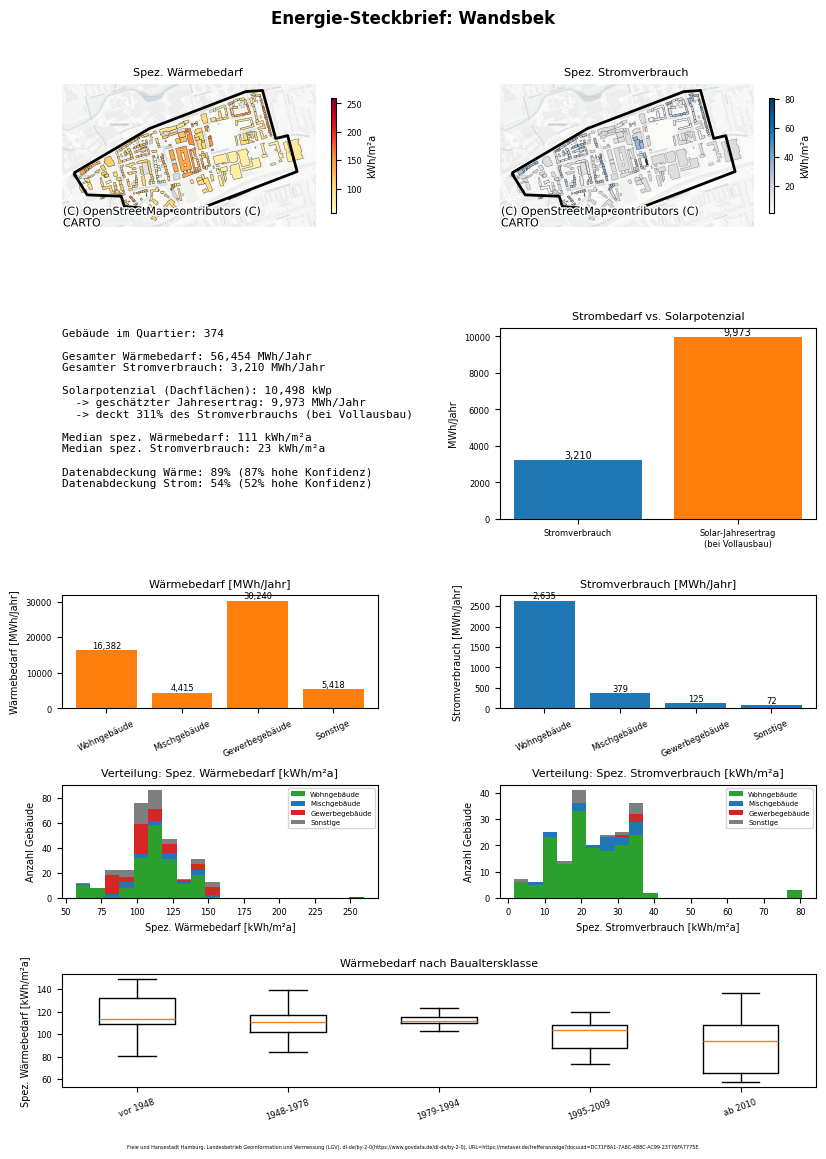

In [7]:
fig, summary_wandsbek = build_energy_report(buildings_unified, districts["Wandsbek"], title="Energie-Steckbrief: Wandsbek", save_file="energy_report_wandsbek.pdf")

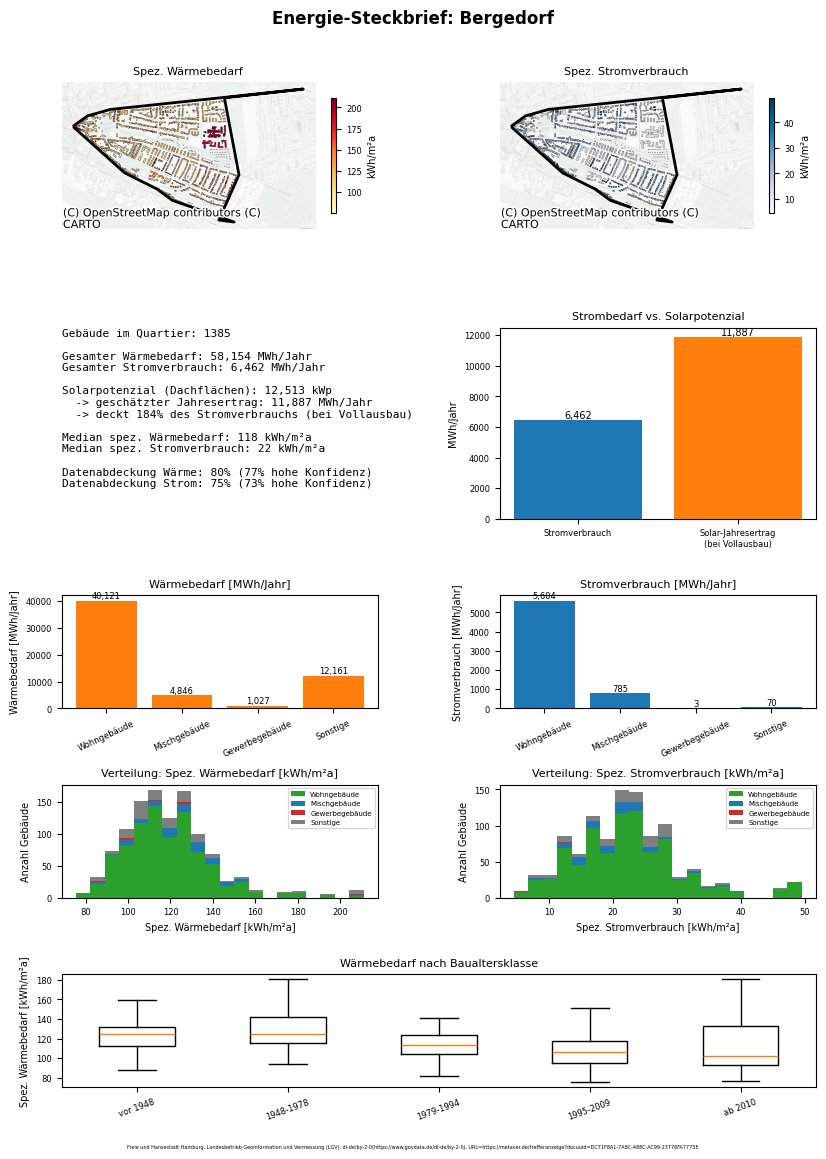

In [8]:
fig, summary_bergedorf = build_energy_report(buildings_unified, districts["Bergedorf"], title="Energie-Steckbrief: Bergedorf", save_file="energy_report_bergedorf.pdf")

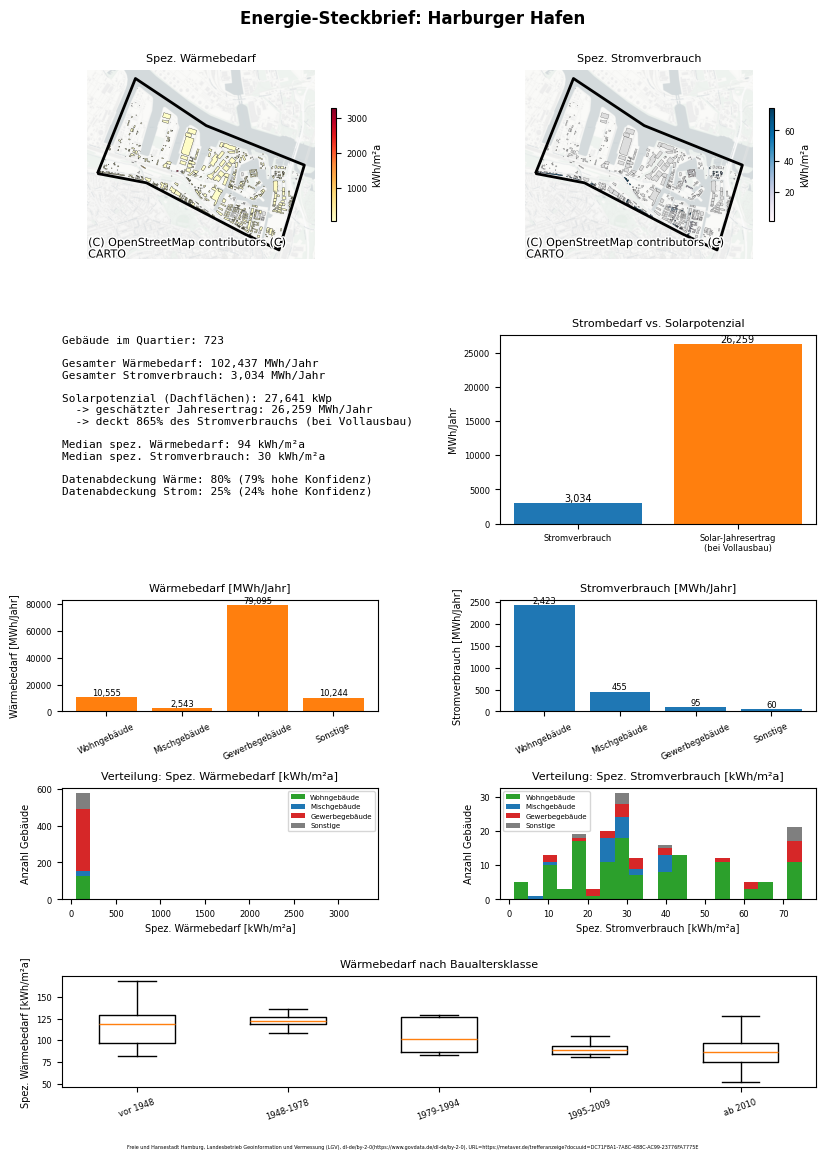

In [9]:
fig, summary_harburg = build_energy_report(buildings_unified, districts["Harburger Hafen"], title="Energie-Steckbrief: Harburger Hafen", save_file="energy_report_harburg_hafen.pdf")

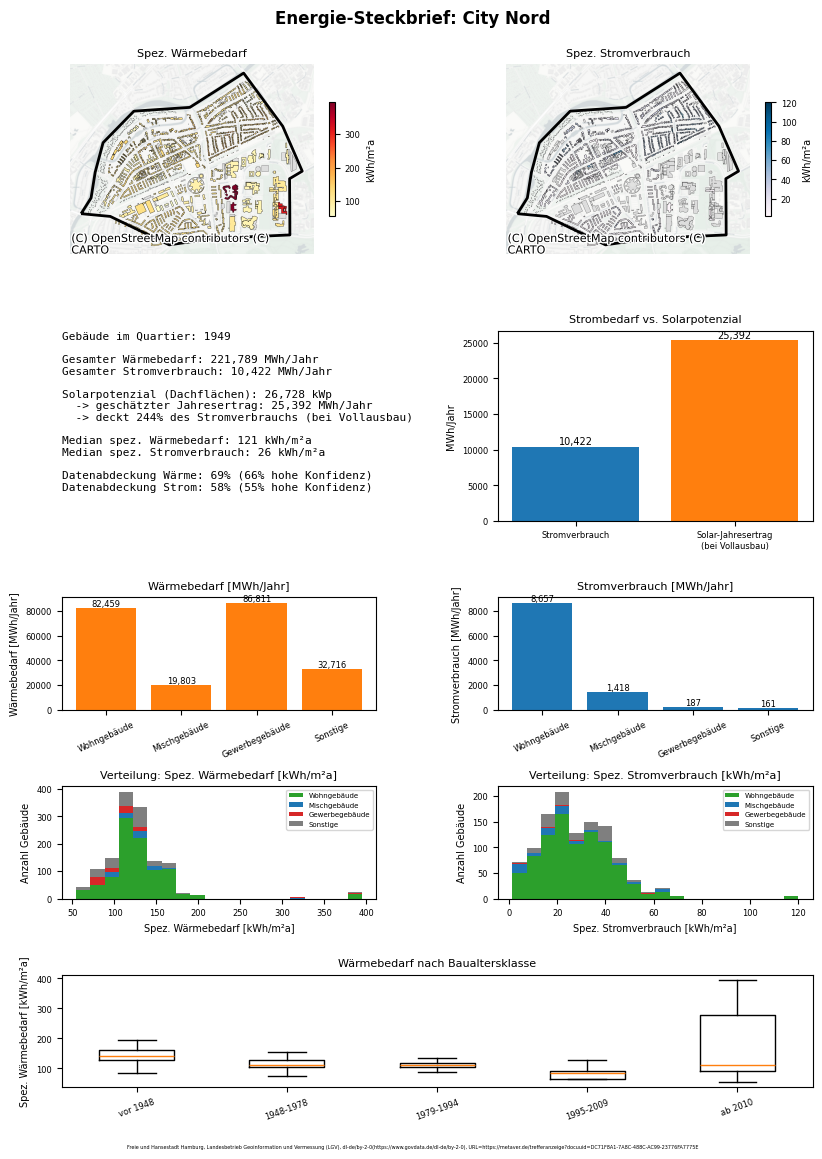

In [10]:
fig, summary_city_nord = build_energy_report(buildings_unified, districts["City Nord"], title="Energie-Steckbrief: City Nord", save_file="energy_report_city_nord.pdf")

## Quartiere im Vergleich

The district as an entirety, side by side: how the four Steckbriefe above compare on total demand,
typical building intensity, and how far rooftop solar could theoretically go toward covering
electricity demand.

In [11]:
summaries = {
    "Wandsbek": summary_wandsbek,
    "Bergedorf": summary_bergedorf,
    "Harburger Hafen": summary_harburg,
    "City Nord": summary_city_nord,
}
comparison = pd.DataFrame(summaries).T
comparison.index.name = "Quartier"
comparison

,n_buildings,total_heat_mwh,total_elec_mwh,total_solar_kwp,total_solar_yield_mwh,solar_coverage_of_elec,median_specific_heat,median_specific_elec,heat_coverage,heat_high_confidence_share,elec_coverage,elec_high_confidence_share
Quartier,,,,,,,,,,,,
Wandsbek,374.0,56454.456489,3210.052223,10498.074254,9973.170541,3.106856,110.666272,23.000000,0.890374,0.866310,0.542781,0.521390
Bergedorf,1385.0,58154.330114,6461.516650,12513.040673,11887.388639,1.839721,117.536434,22.113022,0.797834,0.773285,0.754513,0.728520
Harburger Hafen,723.0,102436.829240,3034.000000,27640.689690,26258.655205,8.654797,93.727273,30.443661,0.800830,0.793914,0.247580,0.242047
City Nord,1949.0,221789.318872,10422.306938,26728.312358,25391.896740,2.436303,121.257642,26.121242,0.689584,0.664956,0.575680,0.554130


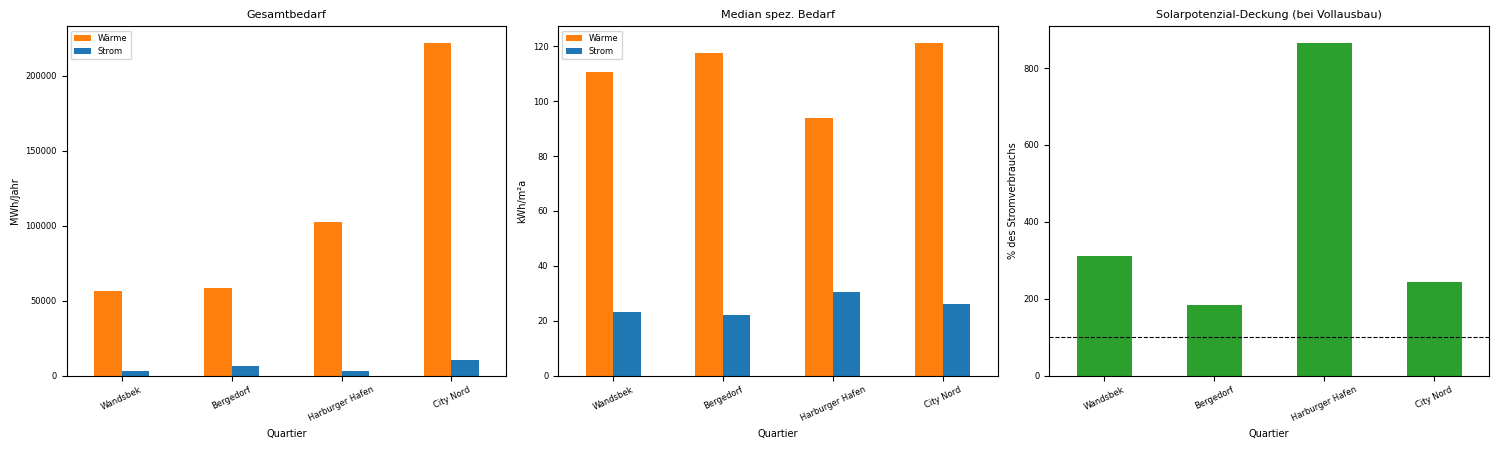

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

comparison[["total_heat_mwh", "total_elec_mwh"]].plot.bar(ax=axes[0], color=["tab:orange", "tab:blue"])
axes[0].set_ylabel("MWh/Jahr")
axes[0].set_title("Gesamtbedarf")
axes[0].legend(["Wärme", "Strom"])
axes[0].tick_params(axis="x", rotation=25)

comparison[["median_specific_heat", "median_specific_elec"]].plot.bar(ax=axes[1], color=["tab:orange", "tab:blue"])
axes[1].set_ylabel("kWh/m²a")
axes[1].set_title("Median spez. Bedarf")
axes[1].legend(["Wärme", "Strom"])
axes[1].tick_params(axis="x", rotation=25)

(comparison["solar_coverage_of_elec"] * 100).plot.bar(ax=axes[2], color="tab:green")
axes[2].axhline(100, color="black", linewidth=0.8, linestyle="--")
axes[2].set_ylabel("% des Stromverbrauchs")
axes[2].set_title("Solarpotenzial-Deckung (bei Vollausbau)")
axes[2].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()